# Parte 1 — Iteración 7: Sin Strip de Acentos y Rango de N-grams Extendido

En la iteración anterior el mejor modelo fue `char TF-IDF (2,6)` con LinearSVC, entrenado sobre el corpus completo. El score en el leaderboard fue 0.29.

La hipótesis de esta iteración es que `strip_accents='unicode'` está descartando información temporal valiosa: el uso de ñ, á, é y otros diacríticos evolucionó considerablemente entre los siglos XVI y XIX. Mantener esos caracteres (`strip_accents=None`) debería mejorar la discriminación entre décadas.

También exploramos extender el rango de n-grams para incluir caracteres individuales (1-grams) o secuencias más largas (7-grams).

## 1. Importación de librerías

In [1]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

## 2. Carga de los datos

In [2]:
TRAIN_PATH = 'train.csv'
EVAL_PATH  = 'eval.csv'
MODEL_PATH = 'best_model_v7.joblib'
SUBMISSION_PATH = 'submission_v7.csv'

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
eval_df  = pd.read_csv(EVAL_PATH)

train_df['text'] = train_df['text'].fillna('')
eval_df['text']  = eval_df['text'].fillna('')

print('Train shape:', train_df.shape)
print('Eval shape: ', eval_df.shape)

Train shape: (31403, 2)
Eval shape:  (3490, 2)


In [4]:
train_df.head(3)

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


## 3. Exploración del conjunto de datos

Revisión rápida de la distribución de clases y estadísticas básicas del texto.

In [5]:
print('Décadas únicas:', sorted(train_df['decade'].unique()))
print('Clases totales:', train_df['decade'].nunique())
print()
print('Distribución (primeras y últimas):')
print(train_df['decade'].value_counts().sort_index())

Décadas únicas: [150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188]
Clases totales: 39

Distribución (primeras y últimas):
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809
Name: count, dtype: int64


In [6]:
train_df['n_chars'] = train_df['text'].str.len()
train_df['n_words'] = train_df['text'].str.split().str.len()

print(f"Media de caracteres: {train_df['n_chars'].mean():.1f}")
print(f"Mediana de caracteres: {train_df['n_chars'].median():.1f}")
print(f"Media de palabras: {train_df['n_words'].mean():.1f}")

Media de caracteres: 520.6
Mediana de caracteres: 315.0
Media de palabras: 82.3


## 4. Partición de los datos

Usamos el mismo split que en iteraciones anteriores para que los resultados sean comparables.

In [7]:
X = train_df['text']
y = train_df['decade']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print('Train:', X_train.shape[0], '| Val:', X_val.shape[0])

Train: 25122 | Val: 6281


## 5. Diseño de experimentos

Definimos una función constructora de pipelines y un diccionario de candidatos. Cada candidato varía en:

- `strip_accents`: `'unicode'` (iter6) vs `None` (hipótesis principal)
- `ngram_range`: distintos rangos que incluyen 1-grams, 7-grams o ambos
- `max_features`: vocabulario más grande a medida que el rango crece
- `C`: valores de regularización para el LinearSVC

In [8]:
def build_char_model(c_value=0.75, ngram_range=(2, 6), max_features=180000,
                     strip_accents=None, min_df=2):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            strip_accents=strip_accents,
            analyzer='char',
            ngram_range=ngram_range,
            min_df=min_df,
            sublinear_tf=True,
            max_features=max_features,
            dtype=np.float32,
        )),
        ('clf', LinearSVC(C=c_value)),
    ])

In [9]:
candidate_models = {
    'baseline_iter6':    build_char_model(c_value=0.75, ngram_range=(2, 6), max_features=180000, strip_accents='unicode'),
    'no_strip_v1':        build_char_model(c_value=0.75, ngram_range=(2, 6), max_features=180000, strip_accents=None),
    'no_strip_v2_1_6':    build_char_model(c_value=0.75, ngram_range=(1, 6), max_features=200000, strip_accents=None),
    'no_strip_v3_2_7':    build_char_model(c_value=0.75, ngram_range=(2, 7), max_features=200000, strip_accents=None),
    'no_strip_v4_1_7':    build_char_model(c_value=0.75, ngram_range=(1, 7), max_features=250000, strip_accents=None),
}

## 6. Entrenamiento y comparación de candidatos

Entrenamos cada candidato en el conjunto de entrenamiento y evaluamos en validación.

In [10]:
results = []

for name, model in candidate_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    preds = model.predict(X_val)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro')

    results.append({'modelo': name, 'val_accuracy': acc, 'macro_f1': f1, 'tiempo_s': round(elapsed, 1)})
    print(f'{name:<28} acc={acc:.4f}  f1={f1:.4f}  ({elapsed:.1f}s)')

baseline_iter6               acc=0.2673  f1=0.2595  (137.3s)
no_strip_v1                  acc=0.2805  f1=0.2731  (137.5s)
no_strip_v2_1_6              acc=0.2815  f1=0.2740  (145.8s)
no_strip_v3_2_7              acc=0.2777  f1=0.2701  (190.4s)
no_strip_v4_1_7              acc=0.2823  f1=0.2748  (206.7s)


In [11]:
results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

         modelo  val_accuracy  macro_f1  tiempo_s
no_strip_v4_1_7      0.282280  0.274786     206.7
no_strip_v2_1_6      0.281484  0.273951     145.8
    no_strip_v1      0.280529  0.273117     137.5
no_strip_v3_2_7      0.277663  0.270137     190.4
 baseline_iter6      0.267314  0.259501     137.3


Con el mejor rango y sin strip de acentos identificado, afinamos el valor de `C`.

In [12]:
best_row      = results_df.iloc[0]
best_name     = best_row['modelo']
best_pipeline = candidate_models[best_name]
best_ngram    = best_pipeline.named_steps['tfidf'].ngram_range
best_maxf     = best_pipeline.named_steps['tfidf'].max_features

print(f'Mejor candidato base: {best_name}')
print(f'ngram_range={best_ngram}, max_features={best_maxf}')

Mejor candidato base: no_strip_v4_1_7
ngram_range=(1, 7), max_features=250000


In [13]:
c_candidates = {}
for c_val in [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    name  = f'c_tuning_{int(c_val*100):03d}'
    model = build_char_model(c_value=c_val, ngram_range=best_ngram,
                              max_features=best_maxf, strip_accents=None)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    preds = model.predict(X_val)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro')

    c_candidates[name] = {'model': model, 'val_accuracy': acc, 'macro_f1': f1, 'C': c_val}
    print(f'{name}  C={c_val:.2f}  acc={acc:.4f}  f1={f1:.4f}  ({elapsed:.1f}s)')

c_tuning_040  C=0.40  acc=0.2842  f1=0.2739  (183.3s)
c_tuning_050  C=0.50  acc=0.2832  f1=0.2739  (194.7s)
c_tuning_060  C=0.60  acc=0.2828  f1=0.2743  (181.3s)
c_tuning_070  C=0.70  acc=0.2828  f1=0.2751  (182.9s)
c_tuning_080  C=0.80  acc=0.2813  f1=0.2739  (190.8s)
c_tuning_090  C=0.90  acc=0.2805  f1=0.2732  (182.3s)


In [14]:
tuning_df = pd.DataFrame([
    {'C': v['C'], 'val_accuracy': v['val_accuracy'], 'macro_f1': v['macro_f1']}
    for v in c_candidates.values()
]).sort_values('val_accuracy', ascending=False)

print(tuning_df.to_string(index=False))

  C  val_accuracy  macro_f1
0.4      0.284190  0.273910
0.5      0.283235  0.273876
0.6      0.282758  0.274294
0.7      0.282758  0.275114
0.8      0.281325  0.273879
0.9      0.280529  0.273227


## 7. Evaluación del mejor modelo

Seleccionamos la mejor combinación final y revisamos el reporte de clasificación completo sobre el conjunto de validación.

In [15]:
best_c_name  = max(c_candidates, key=lambda k: c_candidates[k]['val_accuracy'])
best_c_entry = c_candidates[best_c_name]
best_model   = best_c_entry['model']

print(f'Mejor modelo: {best_c_name}')
print(f"Val accuracy: {best_c_entry['val_accuracy']:.4f}")
print(f"Macro F1:     {best_c_entry['macro_f1']:.4f}")

Mejor modelo: c_tuning_040
Val accuracy: 0.2842
Macro F1:     0.2739


In [16]:
y_val_pred = best_model.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

         150       0.63      0.83      0.72       157
         151       0.54      0.76      0.63       162
         152       0.55      0.66      0.60       157
         153       0.55      0.70      0.62       155
         154       0.51      0.63      0.56       166
         155       0.36      0.29      0.32       167
         156       0.42      0.50      0.46       158
         157       0.31      0.33      0.32       166
         158       0.27      0.28      0.27       156
         159       0.23      0.29      0.26       160
         160       0.13      0.09      0.11       170
         161       0.21      0.18      0.19       157
         162       0.23      0.21      0.22       162
         163       0.14      0.11      0.13       166
         164       0.25      0.24      0.24       161
         165       0.14      0.13      0.13       163
         166       0.10      0.06      0.08       156
         167       0.25    

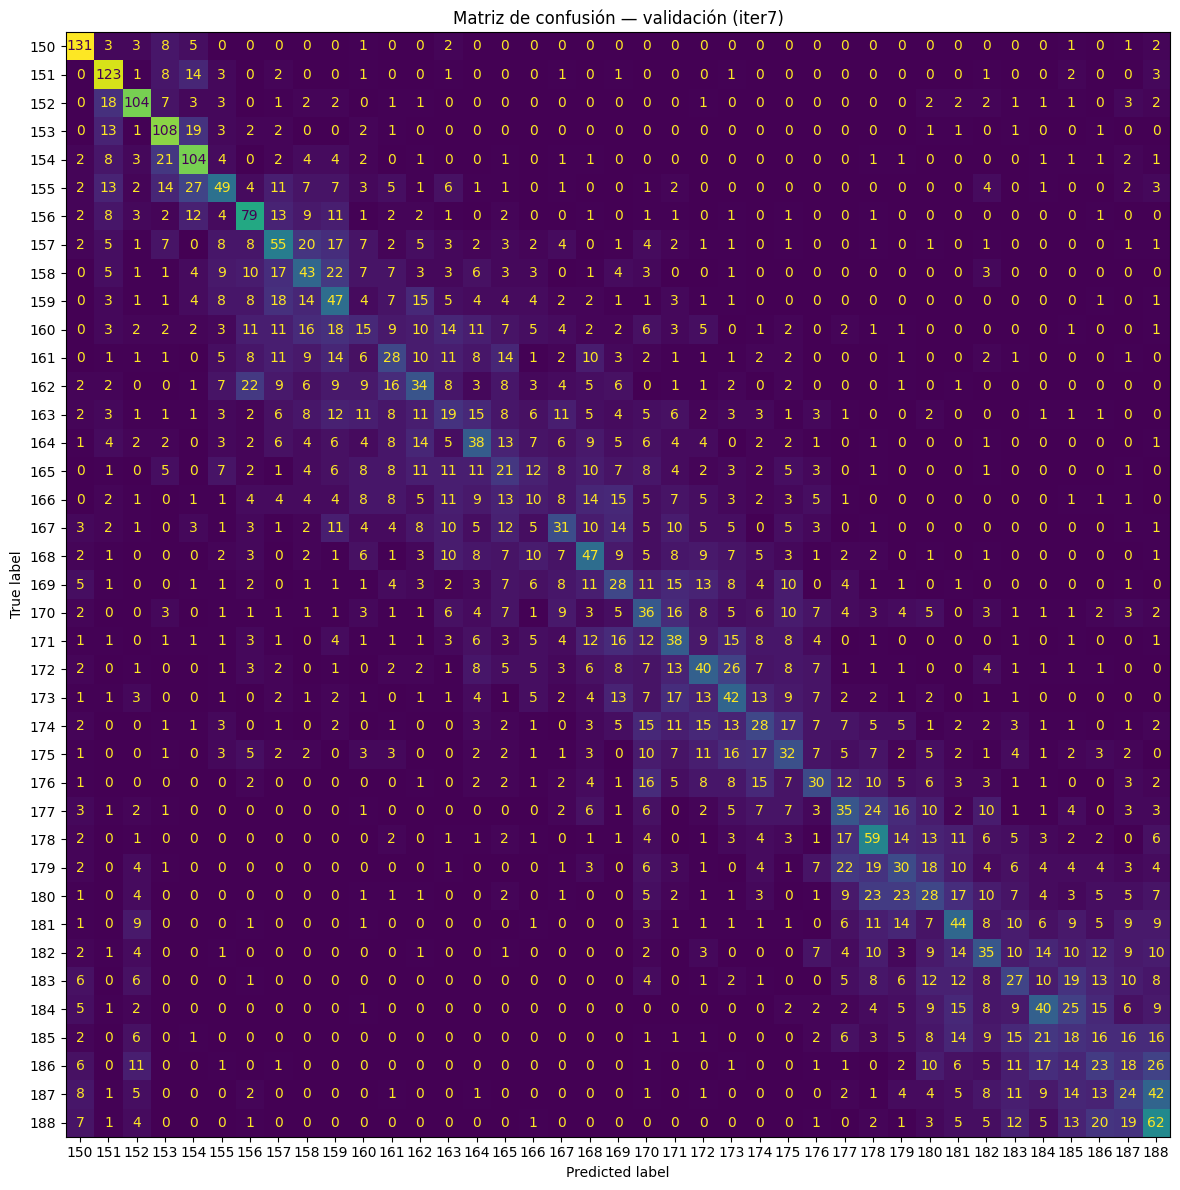

In [17]:
fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, ax=ax, colorbar=False)
plt.title('Matriz de confusión — validación (iter7)')
plt.tight_layout()
plt.show()

## 8. Predicciones sobre eval.csv

Reentrenamos el mejor pipeline sobre el conjunto de entrenamiento completo (train + validación) antes de generar las predicciones finales.

In [18]:
final_model = clone(best_model)
final_model.fit(X, y)

joblib.dump(final_model, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: best_model_v7.joblib


In [19]:
eval_predictions = final_model.predict(eval_df['text']).astype(int)

submission_df = pd.DataFrame({
    'id':     eval_df['id'],
    'answer': eval_predictions,
})
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f'Submission guardado en: {SUBMISSION_PATH}')
submission_df.head()

Submission guardado en: submission_v7.csv


,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153
